## Multiclass Classification

* In the previous challenge, we solved a binary classification problem.  
* What about a **multiclass classification problem**?

🎯 Goals of this exercise:
- Write a Neural Network designed for a multiclass classification problem
- Observe how easily the model can **overfit**… !

## (1) Create a `Blobs` Dataset

📚 Sklearn's **`make_blobs`** function [(see documentation)](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_blobs.html) lets you generate:
- A desired number of data samples (`n_samples` parameter)
- A desired number of features per sample (`n_features` parameter)
- A desired number of classes/categories (`centers` parameter)
- The distance between classes (`cluster_std` parameter)

💡 There is also a `random_state` parameter that ensures the data is generated **deterministically** (the same way each time) and is reproducible.

❓ According to the docs:

👽 Create a ***blobs*** dataset with:
- 1200 samples
- 8 features per sample
- 7 data categories
- Distance between categories: 8

🔮 Set `random_state` equal to 1.

📏 Print the shape and check it matches (1200, 8) for `X` and (1200,) for `y` ❓

In [1]:
from sklearn.datasets import make_blobs

X, y = make_blobs(
    n_samples=1200, 
    n_features=8, 
    centers=7, 
    cluster_std=8, 
    random_state=1
)

X.shape, y.shape


((1200, 8), (1200,))

❓ Using _matplotlib_, plot a scatter plot of two (random) dimensions of this blob dataset. Each point should be colored according to the category it belongs to. ❓

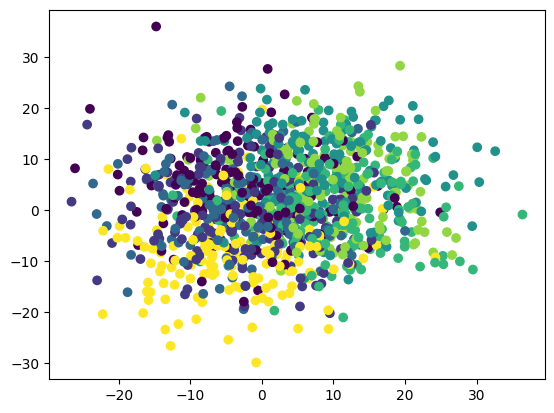

In [ ]:
from matplotlib import pyplot as plt

plt.scatter(X[:, 0], X[:, 1], c=y)
plt.show()

❓ Repeat the same for the other dimensions. You can visually see that the data points are not easily separable ❓

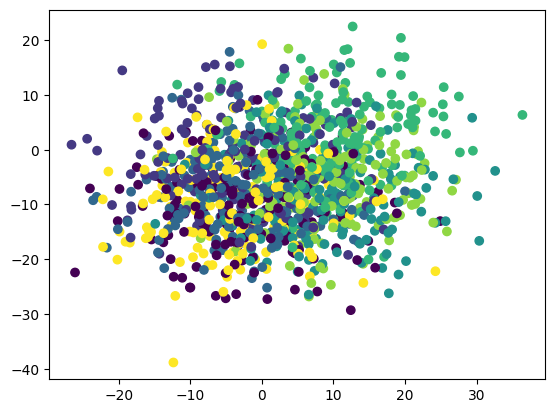

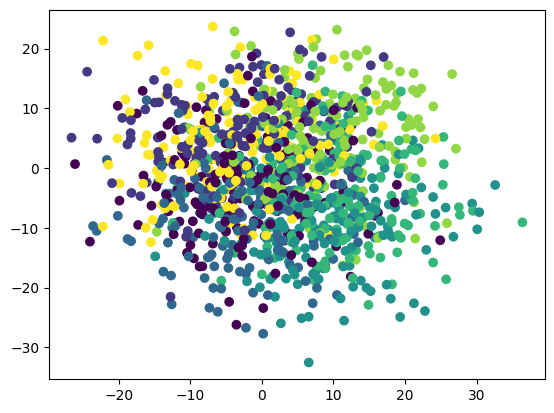

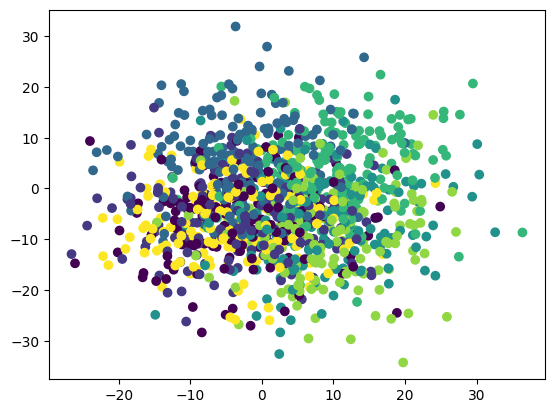

In [3]:
plt.scatter(X[:, 0], X[:, 2], c=y)
plt.show()
plt.scatter(X[:, 0], X[:, 3], c=y)
plt.show()
plt.scatter(X[:, 0], X[:, 4], c=y)
plt.show()

## (2) Encoding the Target for the Multiclass Classification Problem

👉 Currently, the target `y` is a **list of integers** representing the category each input belongs to. It looks like this:  
`[3, 2, 2, 3, 0, 5, 1, 1, 0, 5, ...]`  
(in this example there are **7 categories** from 0 to 6).

🧑🏻‍🏫 However, **in Tensorflow/Keras, the target/output for categorical problems must be encoded as follows**:

```
[
[0, 0, 0, 1, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[0, 0, 1, 0, 0, 0, 0], 
[1, 0, 0, 0, 0, 0, 0], 
[0, 0, 0, 0, 0, 1, 0], 
[0, 1, 0, 0, 0, 0, 0],
[0, 1, 0, 0, 0, 0, 0],
[1, 0, 0, 0, 0, 0, 0],
[0, 0, 0, 0, 0, 0, 1],
...
]
```

Where:
- the number of rows equals the **number of observations**  
- the number of columns equals the **number of distinct categories**  

👉 Each column represents a **category**.  

👉 Each row represents a **target**; a value of `1` indicates the category the input belongs to.  

You can think of a row as a probability vector.

```
Example:
| Cat 0 | Cat 1 | Cat 2 | Cat 3 | Cat 4 | Cat 5 | Cat 6 |
|-------|-------|-------|-------|-------|-------|-------|
| 0     | 0     | 0     | 1     | 0     | 0     | 0     |

This means the corresponding row belongs to Cat 3 with 100% probability.
Cat 3
```


---

💡 Use the **`to_categorical`** function **in Tensorflow/Keras** to convert `y` into categorical format.

<details>
    <summary><i>Is there a similarity between <code>to_categorical</code> in Tensorflow/Keras and <code>OneHotEncoder</code> in Scikit-Learn?</i></summary>

Yes! **`to_categorical`** works like `OneHotEncoder` in Sklearn;  
however, here we are encoding a **categorical target**, not a **categorical feature**.

</details>

---

❓ **Encoding the categorical target**: Print `y`, then apply the *to_categorical* function on *`y`* and save the categorized version of *y* into a variable called `y_cat`. ❓

In [ ]:
print(y)

[2 2 5 ... 1 3 0]


In [5]:
from keras.utils import to_categorical

y_cat = to_categorical(y)
print(y_cat)

[[0. 0. 1. ... 0. 0. 0.]
 [0. 0. 1. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 1. 0.]
 ...
 [0. 1. 0. ... 0. 0. 0.]
 [0. 0. 0. ... 0. 0. 0.]
 [1. 0. 0. ... 0. 0. 0.]]


## (3) Neural Network for the Multiclass Classification Task

❓ **Hold-out method**: Split the dataset $X$ and $y_{cat}$ into _train_ and _test_ sets (size: 70/30%)

Note: Name your variables `X_train`, `X_test`, `y_train` and `y_test` ❓

In [6]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y_cat, test_size=0.3, random_state=1)

In Deep Learning, as with any Machine Learning algorithm, your numerical features should be scaled.

❓ **Scaling**: Fit a Sklearn [`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html) on the training set and transform both your training set and test set ❓

In [7]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

❓ **Initialize the model**: Complete the function below to create/initialize a model with the following properties:
- First layer:
   - 50 neurons
   - `relu` activation
   - Correct input dimension
- Output layer:
   - Designed for a multiclass classification task
   - Outputs the probability of belonging to each class ❓

In [8]:
def initialize_model():

    #############################
    #  1 - Model Architecture   #
    #############################

    from keras.models import Sequential
    from keras.layers import Dense

    model = Sequential()
    
    model.add(Dense(50, input_dim=8, activation='relu'))
    model.add(Dense(7, activation='softmax'))

    #############################
    #  2 - Optimization Method  #
    #############################
    model.compile(loss='categorical_crossentropy', # different from binary_crossentropy because we have more than one class
                  optimizer='adam',
                  metrics=['accuracy'])

    return model


model = initialize_model()

/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


❓ How many parameters (a.k.a. weights) does the model have? ❓

In [9]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 50)             │           450 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 7)              │           357 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 807 (3.15 KB)

 Trainable params: 807 (3.15 KB)

 Non-trainable params: 0 (0.00 B)

❓ **Fitting the model**: Fit your model on the training data for 50 epochs and plot the history ❓

Epoch 1/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7631 - loss: 0.6056 - val_accuracy: 0.6750 - val_loss: 1.0180
Epoch 2/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7667 - loss: 0.6039 - val_accuracy: 0.6667 - val_loss: 1.0174
Epoch 3/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 967us/step - accuracy: 0.7655 - loss: 0.6026 - val_accuracy: 0.6722 - val_loss: 1.0245
Epoch 4/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.7667 - loss: 0.6018 - val_accuracy: 0.6750 - val_loss: 1.0210
Epoch 5/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7643 - loss: 0.6014 - val_accuracy: 0.6806 - val_loss: 1.0219
Epoch 6/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 936us/step - accuracy: 0.7690 - loss: 0.6004 - val_accuracy: 0.6667 - val_loss: 1.0194
Epoch 7/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.7679 - loss: 0.6004 - val_accuracy: 0.6667 - val_loss: 1.0232
Epoch 8/50
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 916us/step - accuracy: 0.7679 - loss: 0.6001 - val_accuracy: 0.6694 - val

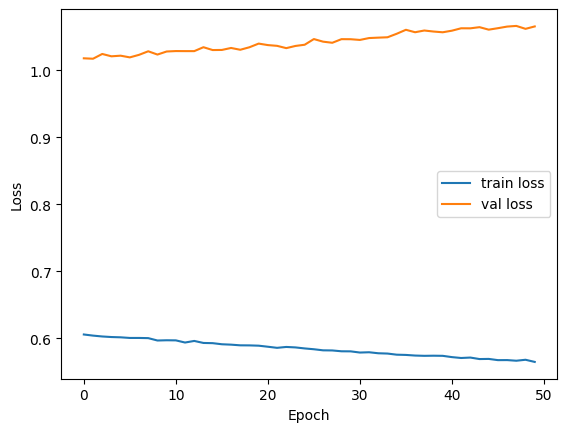

In [ ]:
history = model.fit(X_train, y_train, epochs=50, validation_data=(X_test, y_test))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

❓ **Evaluation**: Evaluate your model on the test set and print the accuracy ❓

In [22]:
loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test loss: {loss}")
print(f"Test accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 818us/step - accuracy: 0.6722 - loss: 1.0656
Test loss: 1.0655781030654907
Test accuracy: 0.6722221970558167


❓ 🤔 Is this a good score? You should compare it against some kind of baseline. In this case, what score could you get with a random guess? Store this baseline score in the `accuracy_baseline` variable. ❓

(You don't need to write code for this, just think about how our dataset was created.)

In [25]:
accuracy_baseline = 1/7

🧪 **Test Your Code**

In [26]:
from nbresult import ChallengeResult
result = ChallengeResult('baseline',
                         accuracy=accuracy_baseline)
result.write()
print(result.check())


============================= test session starts ==============================
platform darwin -- Python 3.12.9, pytest-8.3.4, pluggy-1.5.0 -- /Users/yaren/.pyenv/versions/workintech/bin/python
cachedir: .pytest_cache
rootdir: /Users/yaren/code/ds_projects/data-multiclass-classification/tests
plugins: anyio-4.12.1, dash-4.0.0, typeguard-4.4.2
collecting ... collected 1 item

test_baseline.py::TestBaseline::test_accuracy PASSED                     [100%]

============================== 1 passed in 0.00s ===============================


💯 You can commit your code:

git add tests/baseline.pickle

git commit -m 'Completed baseline step'

git push origin master



❗ 👀 Wait... If you look more closely at the loss graph, after 50 epochs the loss still seems to be decreasing. Why are you stopping so early ❓❗

❓ Let's re-initialize the model and run it again this time with 1000 epochs, and plot the history again. ❓

Epoch 1/1000


/Users/yaren/.pyenv/versions/workintech/lib/python3.12/site-packages/keras/src/layers/core/dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.1726 - loss: 1.9298 - val_accuracy: 0.2222 - val_loss: 1.8283
Epoch 2/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.3202 - loss: 1.7036 - val_accuracy: 0.3500 - val_loss: 1.6458
Epoch 3/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4440 - loss: 1.5265 - val_accuracy: 0.4889 - val_loss: 1.4984
Epoch 4/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 953us/step - accuracy: 0.5524 - loss: 1.3814 - val_accuracy: 0.5778 - val_loss: 1.3678
Epoch 5/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 995us/step - accuracy: 0.6250 - loss: 1.2572 - val_accuracy: 0.6194 - val_loss: 1.2626
Epoch 6/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6536 - loss: 1.1529 - val_accuracy: 0.6333 - val_loss: 1.1761
Epoch 7/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6750 - loss: 1.0673 - val_accuracy: 0.6417 - val_loss: 1.1041
Epoch 8/1000
27/27 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6833 - loss: 0.9985 - val_accuracy: 0.6611 - va

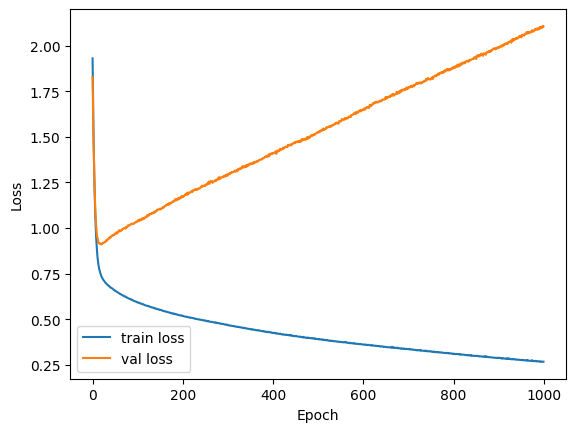

In [27]:
model = initialize_model()

history = model.fit(X_train, y_train, epochs=1000, validation_data=(X_test, y_test))

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

❓ **When training a model for longer...** ❓
- What can you say about the new loss?
- Evaluate your model on the test set once more and print the accuracy.

In [28]:
loss, test_accuracy = model.evaluate(X_test, y_test)

print(f"Test loss: {loss}")
print(f"Test accuracy: {test_accuracy}")

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 775us/step - accuracy: 0.5722 - loss: 2.1041
Test loss: 2.104069232940674
Test accuracy: 0.5722222328186035


* 😁 The loss computed on the training set looks smaller with 1000 epochs compared to 50 epochs.
* 😟 But the accuracy on the test set is worse with 1000 epochs compared to 50 epochs...

❓ What is this phenomenon called? ❓

> overfitting

---

🤔 What should we do to prevent this from happening?

<details>
    <summary><i>Possible options</i></summary>
    

⚠️ To prevent overfitting in neural networks, for example, we can:
1. Choose a ***reasonable number of epochs*** to prevent the neural network from learning too much from noisy data points
2. ***Early Stopping*** criterion, i.e. _.fit()_ 📆 cf. ***Deep Learning > Optimizers, Loss, Fit***

</details>    

---


❓ Let's visually check when the test loss starts increasing again in practice. Run the command below and plot the history ❓

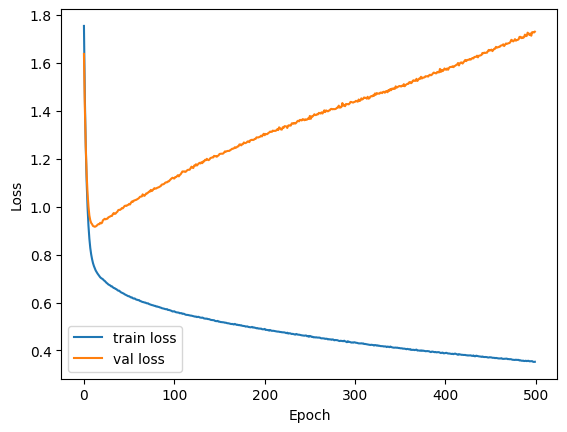

In [30]:
model = initialize_model()

history = model.fit(X_train,
                    y_train,
                    validation_data=(X_test, y_test),
                    epochs=500,
                    batch_size=16,
                    verbose=0)

plt.plot(history.history['loss'], label='train loss')
plt.plot(history.history['val_loss'], label='val loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

😱 But wait... if we use the test set, aren't we cheating? Yes, we are. But be patient. In ***Deep Learning - Optimizers, Loss, Fit***, we'll use what we call a ***Validation Set*** to prevent this!

🧘🏻‍♀️ For now, let's move on to the next questions!

❓ **Evaluating the network**: Plot the loss and accuracy values on the <span style="color:blue">training set</span> and <span style="color:orange">test set</span>. What can you say about this? ❓ 

In [31]:
def plot_loss_accuracy(history):
    plt.plot(history.history['loss'])
    plt.plot(history.history['val_loss'])
    plt.title('Model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

    plt.plot(history.history['accuracy'])
    plt.plot(history.history['val_accuracy'])
    plt.title('Model Accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Train', 'Test'], loc='best')
    plt.show()

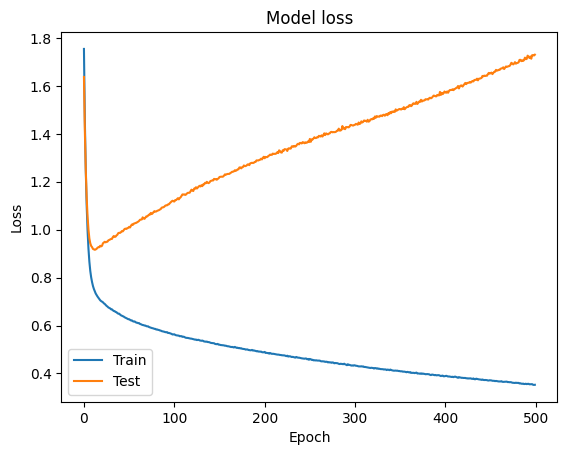

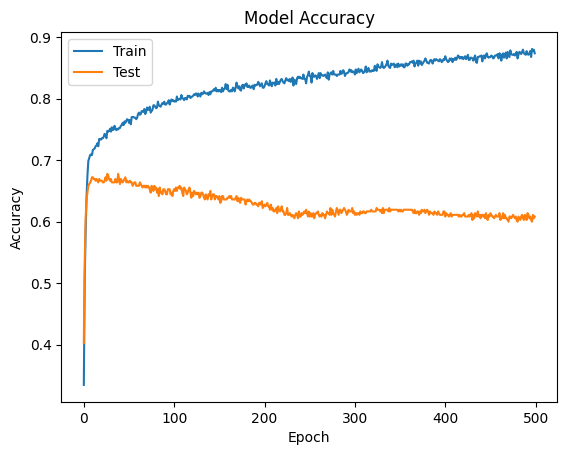

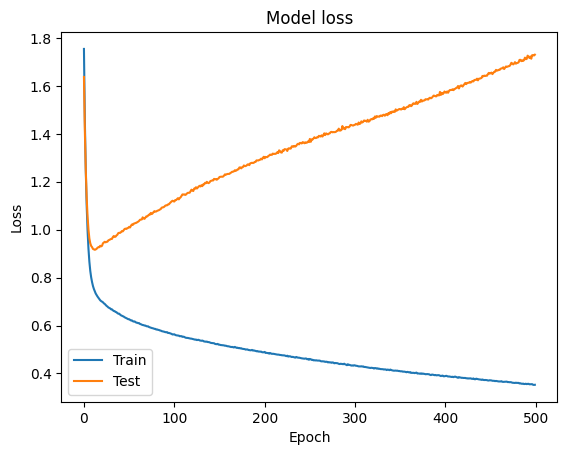

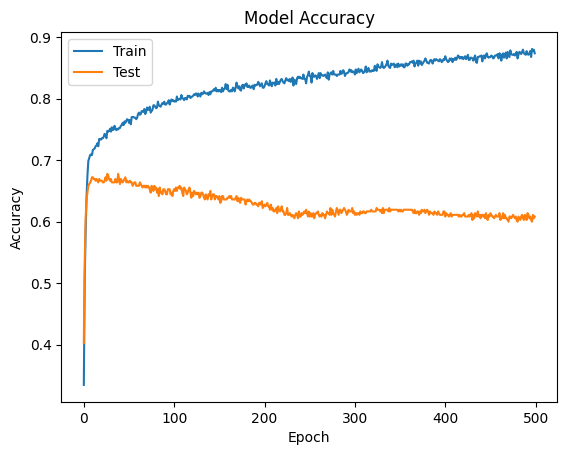

In [32]:
plot_loss_accuracy(history)
plot_loss_accuracy(history)

🤔 Why does our Deep Learning model overfit so easily?

😳 Think about it — our neural network has to learn ~800 parameters for a simple classification task from a dataset with only 8 features! On top of that, we only have ~800 data points to fit on! The model can almost "memorize" the exact class of every point in the training set.

In contrast, a simple Logistic Regression would only need to learn 9 parameters to capture the patterns in this blob dataset! 

😏 Deep learning is an impressive concept, but it can clearly be overkill for simple machine learning tasks!

⭐️ It will be extremely useful for:
- 📸 Image processing
- 💹 Time series
- 🗣 Natural language processing